In [ ]:
import torch
import torch.nn as nn
from transformers import AutoTokenizer, AutoModel
from torch.utils.data import Dataset, DataLoader
from typing import List, Tuple
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix
import matplotlib.pyplot as plt
import joblib

device = torch.device("cuda")

class MetalDataset(Dataset):
    def __init__(self, texts: List[str], numericals: List[float], labels: List[int]):
        self.tokenizer = AutoTokenizer.from_pretrained("cointegrated/rubert-tiny") 
        self.numericals = numericals
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        # Токенизация текста (возвращаем тензоры с batch dim=1)
        text_inputs = self.tokenizer(self.texts[idx], padding="max_length", truncation=True, max_length=32, return_tensors='pt') 
        input_ids = text_inputs["input_ids"].squeeze(0)     
        attention_mask = text_inputs["attention_mask"].squeeze(0)

        # Числовой признак - скалярный тензор
        num_data = torch.tensor(self.numericals[idx], dtype=torch.float32)

        # Метка класса
        label = torch.tensor(self.labels[idx], dtype=torch.long)

        return {"input_ids": input_ids, "attention_mask": attention_mask, "numerical_input": num_data}, label

def collate_fn(batch):

    inputs = {
        "input_ids": torch.stack([item[0]['input_ids'] for item in batch]),          # [batch_size, seq_len]
        "attention_mask": torch.stack([item[0]['attention_mask'] for item in batch]),# [batch_size, seq_len]
        "numerical_input": torch.stack([item[0]['numerical_input'] for item in batch]) 
    }
    labels = torch.stack([item[1] for item in batch]) 
    return inputs, labels

По сути такая же мультимодальная модель как уже делалась, только модель полегче - ruBert tiny v1 по русскоязычным текстам, макс токен в 8 раз меньше, так как по распределению длин токенов до ~30 доходит максимум, в среднем в 1,5-2 раза меньше, количество классов объявлений увеличилось с ~13 до 61, размер батча поменьше для скорости, качество на 0,01-0,02 по метрикам упало по сравнению с моделью для меньшег количества классов

In [16]:
df = pd.read_excel('categs.xlsx')
df = df.dropna(subset=['name', 'price', 'category'])
df = df.drop(['Unnamed: 3', 'Unnamed: 4'], axis=1)

In [17]:
df['category_counts'] = df.groupby(['category'])['name'].transform('count')
df = df[df['category_counts'] > 3] # Убрать малые классы или добавить в них данных #это сделали, только на 1 нужно поменять, остальные берем

In [ ]:
labelencoder = LabelEncoder() 

df.loc[:, 'category'] = labelencoder.fit_transform(df.loc[:, 'category'])
df['category'] = df['category'].astype('int64')
df

,name,price,category,category_counts
0,"""оборонка"" советская от /кг",100.0,44,4966
1,"(10%ni), не габарит нержавеющая сталь ni: 9,8%...",65.0,54,871
2,(10pee) 100% новый hvled815pftr hvled815pf hvl...,943.0,44,4966
3,(12а) жесть (сталь толщиной менее 4 мм),11.0,1,293
4,(12а2) жесть оцинкованная,11.0,1,293
...,...,...,...,...
29803,Металлическая стружка (латунь),361.0,28,429
29804,"Лом: латунь, стружка",341.0,28,429
29805,"Лом: латунь, стружка",208.0,28,429
29806,Лом цветных металлов (стружка латуни),366.0,28,429


In [20]:
unique_cats = len(df['category'].unique())

In [21]:
df['price'] = df['price'].astype(float)

X = df.drop(['category'], axis=1)
y = df[['category']]

Xtrain, Xtest, ytrain, ytest = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

name = list(Xtrain['name'])
price = list(Xtrain['price'])
categories = list(ytrain['category'])

name_val = list(Xtest['name'])
price_val = list(Xtest['price'])
categories_cal = list(ytest['category'])

dataset = MetalDataset(name, price, categories)
val_dataset = MetalDataset(name_val, price_val, categories_cal)

dataloader = DataLoader(dataset, batch_size=8, shuffle=True, collate_fn=collate_fn) # Размер батча тоже подумать, какой лучше, но на 8 у меня все хорошо обучалось # Можно 32 попробовать, так как увеличится количество данных
val_loader = DataLoader(val_dataset, batch_size=8, shuffle=False, collate_fn=collate_fn)

In [22]:
ytrain['category'].value_counts().reset_index()

,category,count
0,44,3973
1,41,900
2,54,697
3,19,683
4,52,645
...,...,...
56,27,176
57,2,124
58,6,83
59,7,82


In [23]:
ytest['category'].value_counts().reset_index()

,category,count
0,44,993
1,41,225
2,54,174
3,19,171
4,52,161
...,...,...
56,27,44
57,2,31
58,6,21
59,7,20


In [ ]:
# Определение моделей
class TextBranch(nn.Module):
    def __init__(self):
        super(TextBranch, self).__init__()
        self.model = AutoModel.from_pretrained("cointegrated/rubert-tiny")
    def forward(self, input_ids, attention_mask):
        outputs = self.model(input_ids=input_ids, attention_mask=attention_mask)
        last_hidden_state_cls = outputs.last_hidden_state[:, 0, :]  
        return last_hidden_state_cls

class NumericalBranch(nn.Module):
    def __init__(self, input_dim):
        super(NumericalBranch, self).__init__()
        self.fc = nn.Linear(input_dim, 64) 
    def forward(self, x):
        return self.fc(x.unsqueeze(1))  

class CombinedModel(nn.Module):
    def __init__(self): 
        self.numerical_branch = NumericalBranch(input_dim=1)
        self.classifier = nn.Sequential(
         #  nn.Linear(768 + 64, 128),
            nn.Linear(376, 128),
            nn.ReLU(),
            nn.Dropout(p=0.2),
            nn.Linear(128, unique_cats)  # количество классов 
        )

    def forward(self, inputs): 
        text_output = self.text_branch(inputs["input_ids"], inputs["attention_mask"])
        numerical_output = self.numerical_branch(inputs["numerical_input"])
        combined_output = torch.cat((text_output, numerical_output), dim=-1)
        output = self.classifier(combined_output)
        return output

Epoch [1/10], Batch [1/2980], Loss: 53.8360
Epoch [1/10], Batch [2/2980], Loss: 25.4310
Epoch [1/10], Batch [3/2980], Loss: 40.3058
Epoch [1/10], Batch [4/2980], Loss: 27.8614
Epoch [1/10], Batch [5/2980], Loss: 36.0224
Epoch [1/10], Batch [6/2980], Loss: 55.7635
Epoch [1/10], Batch [7/2980], Loss: 34.3097
Epoch [1/10], Batch [8/2980], Loss: 36.5173
Epoch [1/10], Batch [9/2980], Loss: 40.0490
Epoch [1/10], Batch [10/2980], Loss: 40.0736
Epoch [1/10], Batch [11/2980], Loss: 16.4023
Epoch [1/10], Batch [12/2980], Loss: 44.4708
Epoch [1/10], Batch [13/2980], Loss: 35.2830
Epoch [1/10], Batch [14/2980], Loss: 52.7611
Epoch [1/10], Batch [15/2980], Loss: 22.0168
Epoch [1/10], Batch [16/2980], Loss: 59.2530
Epoch [1/10], Batch [17/2980], Loss: 42.9988
Epoch [1/10], Batch [18/2980], Loss: 43.5668
Epoch [1/10], Batch [19/2980], Loss: 33.2743
Epoch [1/10], Batch [20/2980], Loss: 30.3262
Epoch [1/10], Batch [21/2980], Loss: 23.6203
Epoch [1/10], Batch [22/2980], Loss: 39.2392
Epoch [1/10], Batch

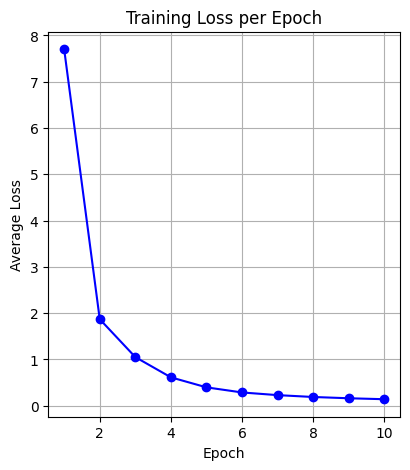

In [ ]:
# Обучение
model = CombinedModel().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-5)

train_losses = []  # Будет хранить средние лоссы за каждую эпоху
batch_losses = []   # Для отладки: лоссы каждого батча
num_epochs = 10

plt.figure(figsize=(10, 5))

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0

    for batch_idx, (data, target) in enumerate(dataloader):
        data = {k: v.to(device) for k, v in data.items()}
        target = target.to(device)

        optimizer.zero_grad()
        output = model(data)
        loss = criterion(output, target)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        batch_losses.append(loss.item())  # Сохраняем лосс батча

        print(f"Epoch [{epoch+1}/{num_epochs}], Batch [{batch_idx+1}/{len(dataloader)}], Loss: {loss.item():.4f}")

    epoch_loss = running_loss / len(dataloader)
    train_losses.append(epoch_loss)
    print(f"Epoch [{epoch+1}/{num_epochs}] Average Loss: {epoch_loss:.4f}")

    plt.clf() 
    
    plt.subplot(1, 2, 1)
    plt.plot(range(1, len(train_losses) + 1), train_losses, marker='o', color='blue')
    plt.xlabel("Epoch")
    plt.ylabel("Average Loss")
    plt.title("Training Loss per Epoch")
    plt.grid(True)

In [ ]:
model.eval()
all_preds = []
all_targets = []
all_probs = []  # Будет хранить максимальные вероятности
all_prob_vectors = []  # Будет хранить все вектора вероятностей

with torch.no_grad():
    for data, target in val_loader:
        data = {k: v.to(device) for k, v in data.items()}
        target = target.to(device)

        output = model(data)
        
        # Применяем softmax для получения вероятностей
        probs = torch.softmax(output, dim=1)
        
        # Получаем предсказанные классы
        preds = torch.argmax(probs, dim=1)
        
        # Сохраняем максимальные вероятности
        max_probs, _ = torch.max(probs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_targets.extend(target.cpu().numpy())
        all_probs.extend(max_probs.cpu().numpy())
        all_prob_vectors.extend(probs.cpu().numpy())

acc = accuracy_score(all_targets, all_preds)
precision, recall, f1, _ = precision_recall_fscore_support(all_targets, all_preds, average='macro')
conf_mat = confusion_matrix(all_targets, all_preds)

print(f"Accuracy: {acc:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")
print(f"Confusion Matrix:\n{conf_mat}")

results_df = pd.DataFrame({
    "true_label": all_targets,
    "pred_label": all_preds,
    "confidence": all_probs  # Максимальная вероятность (уверенность модели)
})

results_df['text'] = name_val[:len(results_df)]  # Берем соответствующие тексты
results_df['price'] = price_val[:len(results_df)]  # Берем соответствующие цены

try:
    labelencoder = joblib.load("label_encoder.pkl")
    results_df['true_category'] = labelencoder.inverse_transform(results_df['true_label'])
    results_df['pred_category'] = labelencoder.inverse_transform(results_df['pred_label'])
except:
    print("Не удалось загрузить label encoder")

results_df.to_csv('validation_results.csv', index=False, encoding='utf-8-sig')

Accuracy: 0.9661
Precision: 0.9568
Recall: 0.9605
F1-score: 0.9578
Confusion Matrix:
[[ 61   0   0 ...   0   0   0]
 [  0  57   0 ...   0   0   0]
 [  0   0  31 ...   0   0   0]
 ...
 [  0   0   0 ...  80   0   0]
 [  0   0   0 ...   0 128   0]
 [  0   0   0 ...   0   0 114]]


C:\Users\Илья\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.9_qbz5n2kfra8p0\LocalCache\local-packages\Python39\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [32]:
model.eval()  

val_loss_total = 0.0
num_batches = 0

with torch.no_grad():  
    for data, target in val_loader:
        data = {k: v.to(device) for k, v in data.items()}
        target = target.to(device)

        output = model(data)
        loss = criterion(output, target)

        val_loss_total += loss.item()
        num_batches += 1

val_loss_avg = val_loss_total / num_batches
print(f"Validation Loss: {val_loss_avg:.4f}")

Validation Loss: 0.1379


In [33]:
torch.save(model, "cointegrated_rubert_tiny_v1_to_classify_scrapmetall_orders.pth")